# Projekt 1.2 — Streuung zum Anfassen

**Phase 1: Deskriptive Statistik & EDA · Schwierigkeit ⭐**

**Konzepte:** Spannweite (range), Varianz (variance), Standardabweichung (standard deviation), IQR (Interquartilsabstand), MAD (median absolute deviation)


## 1. Fragestellung

> **Zwei Kaffeemaschinen füllen im Schnitt gleich viel ein — welche kaufst du, und ab welcher Streuung läuft die Tasse über?**

Der Mittelwert allein ist blind für Streuung. Wir machen die Streuung mit fünf Maßen greifbar und zeigen, dass sie über Erfolg oder Chaos entscheidet.


## 2. Intuition zuerst

**Analogie: der Scharfschütze vs. der Schrotschütze.** Beide zielen auf dieselbe Mitte. Der eine setzt alle Treffer eng zusammen, der andere streut über die ganze Scheibe. Ihr *Durchschnittstreffer* kann identisch sein — trotzdem willst du im Ernstfall den Präzisen.

Genau so hier: Maschine A und B zielen beide auf 235 ml. Bei 250 ml läuft die Tasse über, bei zu wenig fühlt sich der Kunde betrogen. **Streuung ist Risiko.**

Fünf Wege, Streuung zu messen — zwei Familien:
- **Momentbasiert (empfindlich gegen Ausreißer):** Spannweite, Varianz, Standardabweichung
- **Rangbasiert (robust gegen Ausreißer):** IQR, MAD

**Vorhersage (vor dem Rechnen notieren):** Wenn wir 5 grobe Fehlbefüllungen (~400 ml) einstreuen — welche Maße verdoppeln/verdreifachen sich, welche zucken kaum?


## 3. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

REPO_ROOT = Path.cwd().parents[1]
sys.path.append(str(REPO_ROOT))
sys.path.append(str(Path.cwd() / "data"))

from utils import apply_house_style, add_truth_line
import generate_data as gd

apply_house_style()
print("Sollwert:", gd.TARGET_ML, "ml | Fassungsvermögen:", gd.CUP_CAPACITY_ML, "ml | n:", gd.N)

Sollwert: 235.0 ml | Fassungsvermögen: 250.0 ml | n: 10000


## 4. Daten — der wahre DGP

Beide Maschinen: Füllmenge ~ Normal(μ=235 ml, σ=?). Der **einzige** Unterschied ist σ:
- **Maschine A (präzise):** σ = 5 ml
- **Maschine B (schludrig):** σ = 15 ml

Gleicher Erwartungswert, gleiche Verteilungsform — nur die Breite unterscheidet sich. Das isoliert den Effekt der Streuung sauber.


In [2]:
data = gd.generate()
a, b = data["machine_a"], data["machine_b"]
print(f"Maschine A: mean={a.mean():.2f} ml   |  Maschine B: mean={b.mean():.2f} ml")
print("-> praktisch identischer Mittelwert. Der Unterschied MUSS in der Streuung liegen.")

Maschine A: mean=234.95 ml   |  Maschine B: mean=235.31 ml
-> praktisch identischer Mittelwert. Der Unterschied MUSS in der Streuung liegen.


## 5. Die naive (falsche) Herangehensweise

Ein Einkäufer vergleicht nur die Mittelwerte: *„Beide füllen 235 ml — egal welche, kauf die billigere."* Dieser Blick ist buchstäblich blind für das, was den Kunden ärgert (überlaufende oder halbleere Tassen). Wir machen den blinden Fleck sichtbar.


## 6. Kernanalyse — fünf Streuungsmaße von Hand

Formeln, die wir gleich selbst codieren:
- **Spannweite:** $\max - \min$
- **Varianz:** $s^2 = \frac{1}{n-\text{ddof}}\sum (x_i-\bar x)^2$  (ddof=1 = Stichprobenvarianz)
- **Standardabweichung:** $s = \sqrt{s^2}$ — zurück in der Einheit der Daten (ml)
- **IQR:** $Q_{0.75}-Q_{0.25}$ — die Breite der mittleren 50 %
- **MAD:** $\text{median}(|x_i - \text{median}(x)|)$ — der „Median der Abweichungen"


In [3]:
def range_by_hand(x: np.ndarray) -> float:
    """Spannweite = Maximum - Minimum. Nutzt NUR die zwei extremsten Werte
    -> maximal ausreißer-empfindlich."""
    x = np.asarray(x, float)
    return float(x.max() - x.min())


def variance_by_hand(x: np.ndarray, ddof: int = 1) -> float:
    """Varianz = mittlere quadrierte Abweichung vom Mittelwert.

    ddof=1 (Bessel-Korrektur) teilt durch n-1 statt n und macht die
    Stichprobenvarianz erwartungstreu für die Populationsvarianz. Einheit: ml².
    """
    x = np.asarray(x, float)
    xbar = x.mean()
    return float(np.sum((x - xbar) ** 2) / (x.size - ddof))


def std_by_hand(x: np.ndarray, ddof: int = 1) -> float:
    """Standardabweichung = Wurzel der Varianz -> zurück in der Einheit (ml)."""
    return float(np.sqrt(variance_by_hand(x, ddof)))


def quantile_by_hand(x: np.ndarray, p: float) -> float:
    """Empirisches p-Quantil mit linearer Interpolation (wie np.quantile default).

    Rangposition h=(n-1)*p; zwischen den zwei umliegenden sortierten Werten wird
    linear interpoliert. (Vertieft in Projekt 1.5.)
    """
    xs = np.sort(np.asarray(x, float))
    h = (xs.size - 1) * p
    lo = int(np.floor(h))
    frac = h - lo
    if lo + 1 < xs.size:
        return float(xs[lo] + frac * (xs[lo + 1] - xs[lo]))
    return float(xs[lo])


def iqr_by_hand(x: np.ndarray) -> float:
    """IQR = Q0.75 - Q0.25: Breite der mittleren 50 % der Daten.
    Ignoriert die äußeren 25 % je Seite -> robust gegen Ausreißer."""
    return quantile_by_hand(x, 0.75) - quantile_by_hand(x, 0.25)


def mad_by_hand(x: np.ndarray, scale: bool = False) -> float:
    """MAD = median(|x - median(x)|).

    Median statt Mittelwert und Betrag statt Quadrat -> doppelt robust.
    Mit scale=True wird mit 1.4826 multipliziert, damit die MAD bei
    Normalverteilung dasselbe schätzt wie die Standardabweichung (Konsistenz).
    """
    x = np.asarray(x, float)
    med = np.median(x)
    raw = float(np.median(np.abs(x - med)))
    return raw * 1.4826 if scale else raw


Streuungs-Steckbrief beider Maschinen:

In [4]:
import pandas as pd
def profile(x):
    return {
        "Spannweite": range_by_hand(x),
        "Varianz (ml²)": variance_by_hand(x),
        "Std (ml)": std_by_hand(x),
        "IQR (ml)": iqr_by_hand(x),
        "MAD (ml)": mad_by_hand(x),
    }
disp = pd.DataFrame({"Maschine A": profile(a), "Maschine B": profile(b)})
disp.round(2)

,Maschine A,Maschine B
Spannweite,42.07,120.59
Varianz (ml²),25.32,226.32
Std (ml),5.03,15.04
IQR (ml),6.64,20.37
MAD (ml),3.32,10.19


## 7. Verifikation

**(a) Hand vs. NumPy/SciPy.**

In [5]:
for x in (a, b):
    assert np.isclose(variance_by_hand(x), np.var(x, ddof=1))
    assert np.isclose(std_by_hand(x), np.std(x, ddof=1))
    assert np.isclose(iqr_by_hand(x), stats.iqr(x))
    assert np.isclose(mad_by_hand(x), stats.median_abs_deviation(x))
    assert np.isclose(range_by_hand(x), np.ptp(x))
print("Alle fünf Streuungsmaße stimmen mit NumPy/SciPy überein. ✅")

Alle fünf Streuungsmaße stimmen mit NumPy/SciPy überein. ✅


**(b) Simulation vs. Formel — Überlaufwahrscheinlichkeit.**
Für Normal(235, σ) gilt analytisch: $P(X>250) = 1-\Phi\!\left(\frac{250-235}{\sigma}\right)$. Wir vergleichen mit dem simulierten Anteil.


In [6]:
for name, x, sd in [("A", a, gd.MACHINE_A_SD), ("B", b, gd.MACHINE_B_SD)]:
    sim = np.mean(x > gd.CUP_CAPACITY_ML)
    z = (gd.CUP_CAPACITY_ML - gd.TARGET_ML) / sd
    analytic = 1 - stats.norm.cdf(z)
    print(f"Maschine {name} (σ={sd:>4.1f}): Überlauf simuliert {sim*100:6.2f}%  "
          f"| Formel {analytic*100:6.2f}%")

Maschine A (σ= 5.0): Überlauf simuliert   0.17%  | Formel   0.13%
Maschine B (σ=15.0): Überlauf simuliert  16.99%  | Formel  15.87%


## 8. Visualisierung

**Plot 1: Gleiche Mitte, anderes Risiko.** Beide Verteilungen mit Sollwert und Überlauf-Grenze; die Überlauf-Zone ist rot schattiert.


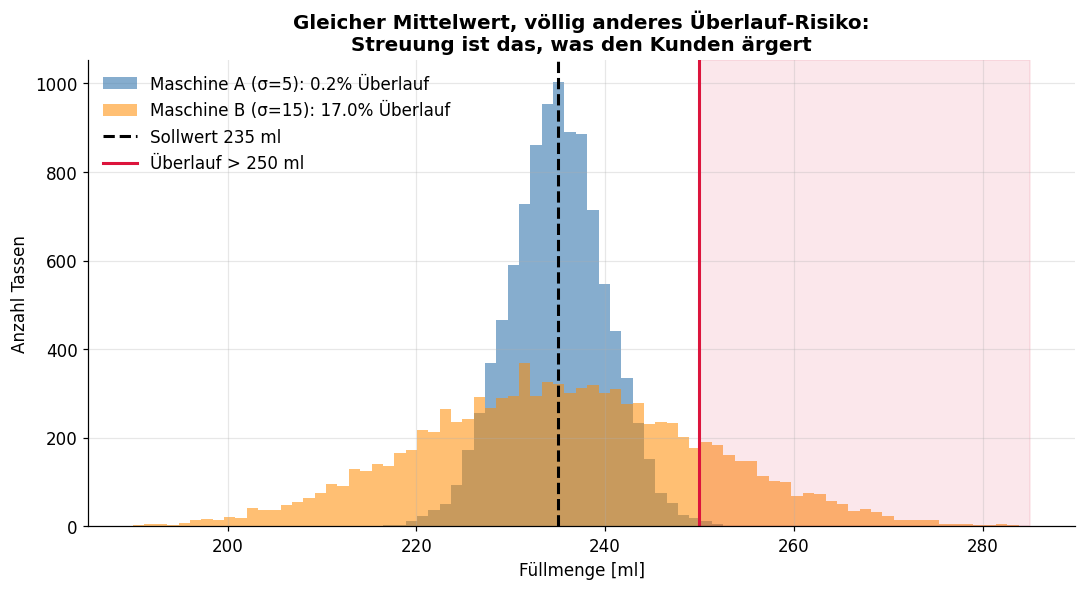

In [7]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bins = np.linspace(190, 285, 80)
ax.hist(a, bins=bins, alpha=0.65, color="steelblue", label=f"Maschine A (σ=5): {np.mean(a>250)*100:.1f}% Überlauf")
ax.hist(b, bins=bins, alpha=0.55, color="darkorange", label=f"Maschine B (σ=15): {np.mean(b>250)*100:.1f}% Überlauf")
add_truth_line(ax, gd.TARGET_ML, label=f"Sollwert {gd.TARGET_ML:.0f} ml", color="black")
ax.axvline(gd.CUP_CAPACITY_ML, color="crimson", lw=2, label=f"Überlauf > {gd.CUP_CAPACITY_ML:.0f} ml")
ax.axvspan(gd.CUP_CAPACITY_ML, 285, color="crimson", alpha=0.10)
ax.set_xlabel("Füllmenge [ml]"); ax.set_ylabel("Anzahl Tassen")
ax.set_title("Gleicher Mittelwert, völlig anderes Überlauf-Risiko:\nStreuung ist das, was den Kunden ärgert")
ax.legend()
fig.tight_layout(); plt.show()

**Plot 2: Ab welcher Streuung wird es kritisch?** Wir tragen die (analytische) Überlaufwahrscheinlichkeit gegen σ auf und markieren die größte noch tolerierbare Streuung für ein 1-%-Ziel.


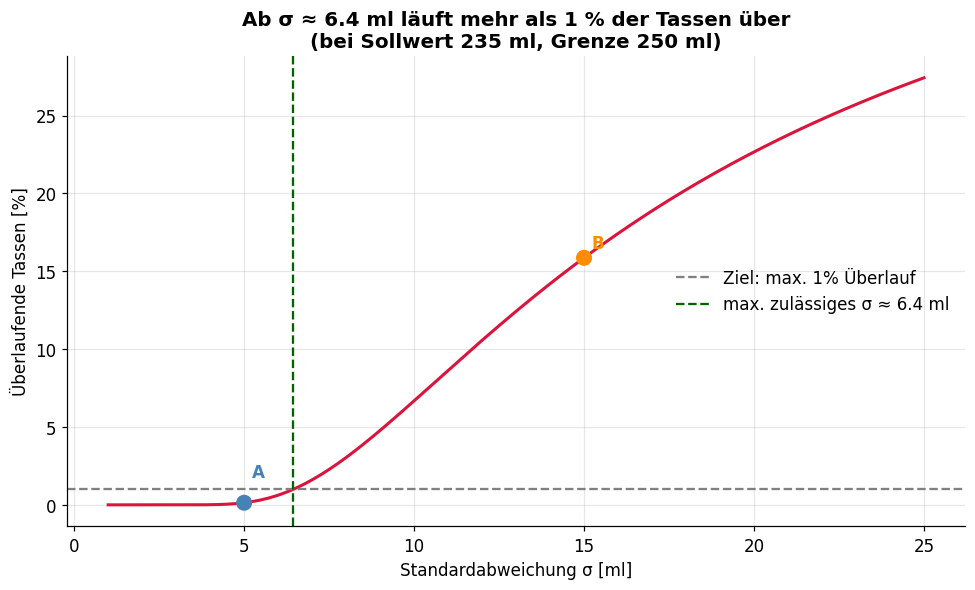

Um unter 1% Überlauf zu bleiben, darf σ höchstens 6.45 ml sein.
-> Maschine A (σ=5) schafft das locker, Maschine B (σ=15) reißt es klar.


In [8]:
sigmas = np.linspace(1, 25, 200)
p_overflow = 1 - stats.norm.cdf((gd.CUP_CAPACITY_ML - gd.TARGET_ML) / sigmas)

TARGET_RATE = 0.01  # wir tolerieren höchstens 1% überlaufende Tassen
z_target = stats.norm.ppf(1 - TARGET_RATE)
sigma_max = (gd.CUP_CAPACITY_ML - gd.TARGET_ML) / z_target  # größtes zulässiges σ

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(sigmas, p_overflow * 100, color="crimson", lw=2)
ax.axhline(TARGET_RATE * 100, ls="--", color="gray", label=f"Ziel: max. {TARGET_RATE*100:.0f}% Überlauf")
ax.axvline(sigma_max, ls="--", color="darkgreen", label=f"max. zulässiges σ ≈ {sigma_max:.1f} ml")
ax.scatter([gd.MACHINE_A_SD, gd.MACHINE_B_SD],
           [(1-stats.norm.cdf((250-235)/gd.MACHINE_A_SD))*100,
            (1-stats.norm.cdf((250-235)/gd.MACHINE_B_SD))*100],
           color=["steelblue", "darkorange"], s=90, zorder=5)
ax.annotate("A", (gd.MACHINE_A_SD, 1), textcoords="offset points", xytext=(5, 8), color="steelblue", fontweight="bold")
ax.annotate("B", (gd.MACHINE_B_SD, 16), textcoords="offset points", xytext=(5, 5), color="darkorange", fontweight="bold")
ax.set_xlabel("Standardabweichung σ [ml]"); ax.set_ylabel("Überlaufende Tassen [%]")
ax.set_title(f"Ab σ ≈ {sigma_max:.1f} ml läuft mehr als 1 % der Tassen über\n(bei Sollwert 235 ml, Grenze 250 ml)")
ax.legend()
fig.tight_layout(); plt.show()
print(f"Um unter {TARGET_RATE*100:.0f}% Überlauf zu bleiben, darf σ höchstens {sigma_max:.2f} ml sein.")
print(f"-> Maschine A (σ=5) schafft das locker, Maschine B (σ=15) reißt es klar.")

## 9. Kaufentscheidung

**Maschine A.** Beide treffen den Sollwert 235 ml im Mittel, aber A hält die Füllmenge eng zusammen: unter 1 % Überlauf gegenüber ~17 % bei B. Bei gleichem Mittelwert entscheidet allein die Streuung — und die ist bei A rund dreimal kleiner. Der Sollwert 235 ml selbst ist übrigens gut gewählt (15 ml Sicherheitsabstand zur Grenze); bei einem knapperen Sollwert würde die Streuung noch kritischer.


## 10. Interpretation *(von dir — 3–5 Sätze, Alltagssprache)*

> Erkläre in eigenen Worten, warum zwei Prozesse mit identischem Mittelwert unterschiedlich „gut" sein können, und was der Unterschied zwischen SD und IQR/MAD praktisch bedeutet. Platzhalter — deine Fassung kommt in `NOTIZEN.md`.


## 11. Stretch Goal — Robustheit: 5 Ausreißer, zwei Reaktionen

Wir streuen 5 grobe Fehlbefüllungen (~400 ml) in Maschine A und schauen, welche Maße explodieren und welche stabil bleiben.


In [9]:
a_out = gd.add_outliers(a, n_out=5)   # 5 von 10.000 Werten auf ~400 ml gesetzt

comparison = pd.DataFrame({
    "ohne Ausreißer": profile(a),
    "mit 5 Ausreißern": profile(a_out),
})
comparison["Faktor"] = (comparison["mit 5 Ausreißern"] / comparison["ohne Ausreißer"]).round(2)
comparison.round(2)

,ohne Ausreißer,mit 5 Ausreißern,Faktor
Spannweite,42.07,197.02,4.68
Varianz (ml²),25.32,38.45,1.52
Std (ml),5.03,6.20,1.23
IQR (ml),6.64,6.64,1.00
MAD (ml),3.32,3.32,1.00


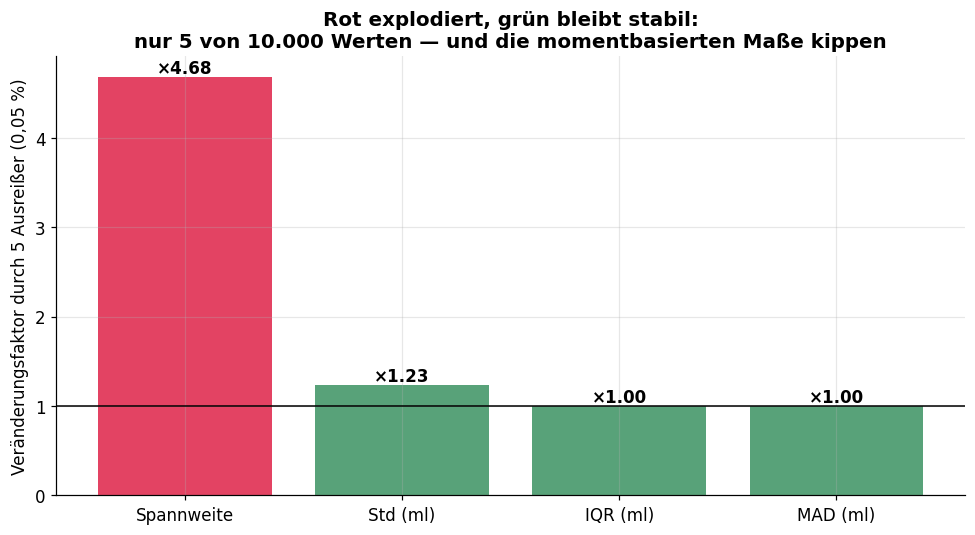

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
measures = ["Spannweite", "Std (ml)", "IQR (ml)", "MAD (ml)"]
factors = [comparison.loc[m, "Faktor"] for m in measures]
colors = ["crimson" if f > 1.5 else "seagreen" for f in factors]
bars = ax.bar(measures, factors, color=colors, alpha=0.8)
ax.axhline(1.0, color="black", lw=1)
for bar, f in zip(bars, factors):
    ax.text(bar.get_x()+bar.get_width()/2, f, f"×{f:.2f}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Veränderungsfaktor durch 5 Ausreißer (0,05 %)")
ax.set_title("Rot explodiert, grün bleibt stabil:\nnur 5 von 10.000 Werten — und die momentbasierten Maße kippen")
fig.tight_layout(); plt.show()

**Lektion:** 5 von 10.000 Werten (0,05 %) verändern Spannweite und Standardabweichung dramatisch, während IQR und MAD kaum zucken. Wenn Ausreißer möglich sind (und das sind sie fast immer), sind **robuste** Streuungsmaße die ehrlichere Wahl — spätestens ab hier lohnt sich der Median-Blick aus Projekt 1.1.

---
**Verbindungen:** Robustheit des Medians → **1.1**. Quantile mit Interpolation vertieft **1.5**. Die Standardabweichung als Baustein des Standardfehlers kommt in **4.2** wieder (SE = σ/√n).
